# Clasificación Intel Image Classification  
### CNN desde cero + Transfer Learning (ResNet / MobileNet) + Visualizaciones  
#### Framework: PyTorch — Google Colab

## 1. Setup e Imports
- Verificar GPU
- Instalar dependencias adicionales (si hace falta)
- Importar librerías principales
- Fijar semillas para reproducibilidad
*italicized text*

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models

# Semillas
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


In [2]:

def set_device():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device != "cuda":
        print(
            "WARNING: GPU no detectada.\n"
            "En Google Colab: Runtime -> Change runtime type -> GPU\n"
        )
    else:
        print("GPU habilitada:", torch.cuda.get_device_name(0))
    return device

DEVICE = set_device()
DEVICE


GPU habilitada: Tesla T4


'cuda'

## 2. Descarga y Exploración del Dataset Intel

- Descargar dataset (Kaggle o link directo)
- Extraer carpetas
- Visualizar ejemplos
- Mostrar distribución de clases


### Importar kaggle.json para descargar dataset

In [8]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"josorioam404","key":"dcbcfc9e249bb7eecc771d29c12e0c94"}'}

In [9]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


### Descarga del dataset

In [10]:
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 86% 299M/346M [00:01<00:00, 176MB/s] 
100% 346M/346M [00:01<00:00, 209MB/s]


In [11]:
!unzip -q intel-image-classification.zip -d /content/intel_data


### Verificación de estructura

In [13]:
train_dir = "/content/intel_data/seg_train/seg_train"
test_dir  = "/content/intel_data/seg_test/seg_test"

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))


Train classes: ['sea', 'street', 'forest', 'buildings', 'mountain', 'glacier']
Test classes: ['sea', 'street', 'forest', 'buildings', 'mountain', 'glacier']


Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


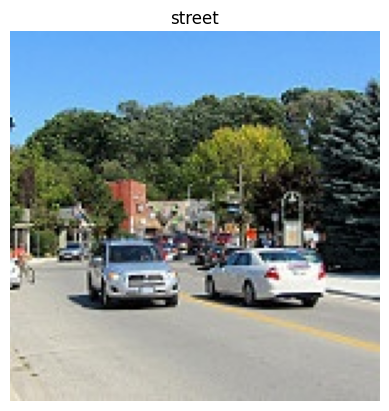

In [15]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

dataset_path = "/content/intel_data/seg_train/seg_train"

# Obtener clases
classes = sorted(os.listdir(dataset_path))
print("Clases:", classes)

# Elegir clase aleatoria
sample_class = random.choice(classes)
sample_path = os.path.join(dataset_path, sample_class)

# Elegir imagen aleatoria
sample_image = os.path.join(sample_path, random.choice(os.listdir(sample_path)))

# Mostrar imagen
img = mpimg.imread(sample_image)
plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()


## 3. Data Augmentation y DataLoaders
- Definir transformaciones para train / val / test
- Crear dataset general
- Definir splits
- Crear DataLoaders


In [50]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Transformaciones
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),            # tamaño estándar para transfer learning
    transforms.RandomHorizontalFlip(),         # flip aleatorio
    transforms.RandomRotation(10),             # rotación ligera
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02
    ),                                         # variaciones de color
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],            # normalización ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Cargar datasets originales
train_full = ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = ImageFolder(root=test_dir, transform=test_transforms)

# División train/val (15% para validación)
val_size = int(0.15 * len(train_full))
train_size = len(train_full) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,   # evitar caídas de workers en Colab
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    pin_memory=False
)

print("Tamaño train:", len(train_dataset))
print("Tamaño val:", len(val_dataset))
print("Tamaño test:", len(test_dataset))


Tamaño train: 11929
Tamaño val: 2105
Tamaño test: 3000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 4. Modelo CNN desde Cero
Arquitectura:
- 3 bloques Conv2D
- BatchNorm + ReLU + MaxPool
- Dense final
- Dropout

Después:
- Definir función de entrenamiento
- Entrenar el modelo


In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class IntelCNN(nn.Module):
    padding = 1
    stride = 1
    kernel_size = 3

    # Filtros por bloque
    f1 = 32
    f2 = 64
    f3 = 128

    def __init__(self, num_classes=6):
        super(IntelCNN, self).__init__()

        # ---- CONV BLOCK 1 ----
        self.conv1 = nn.Conv2d(3, self.f1, kernel_size=self.kernel_size,
                               padding=self.padding, stride=self.stride)
        self.bn1 = nn.BatchNorm2d(self.f1)

        # ---- CONV BLOCK 2 ----
        self.conv2 = nn.Conv2d(self.f1, self.f2, kernel_size=self.kernel_size,
                               padding=self.padding, stride=self.stride)
        self.bn2 = nn.BatchNorm2d(self.f2)

        # ---- CONV BLOCK 3 ----
        self.conv3 = nn.Conv2d(self.f2, self.f3, kernel_size=self.kernel_size,
                               padding=self.padding, stride=self.stride)
        self.bn3 = nn.BatchNorm2d(self.f3)

        # Max pool
        self.pool = nn.MaxPool2d(2)

        # Linear layers (se calcularán dinámicamente)
        self._initialize_fc(num_classes)

    def _initialize_fc(self, num_classes):
        # Creamos un tensor dummy para calcular las dimensiones finales
        x = torch.zeros(1, 3, 224, 224)

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        flatten_dim = x.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flatten_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # ---- BLOCK 1 ----
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # ---- BLOCK 2 ----
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # ---- BLOCK 3 ----
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)

        # ---- FC ----
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def predict(self, x):
        output = self.forward(x)
        return torch.argmax(output, 1)


### Funciones de entrenamiento y validación

In [52]:
from tqdm import tqdm
import time
import torch.nn.functional as F

def train(model, device, train_loader, val_loader, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0

        loop = tqdm(train_loader, unit='batch', desc=f"Epoch {epoch+1}/{epochs}")

        # entrenamiento
        for data, target in loop:
            data, target = data.to(device), target.to(device).long()

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            # Loss acumulado
            total_loss += loss.item()

            # precisión
            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # validación
        model.eval()
        val_loss = 0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device).long()

                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item()

                _, predicted = torch.max(output, 1)
                total_val += target.size(0)
                correct_val += (predicted == target).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train Loss={avg_train_loss:.4f} | Train Acc={train_acc:.2f}% | "
              f"Val Loss={avg_val_loss:.4f} | Val Acc={val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs


def test(model, device, data_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


### Loop de entrenamiento completo

In [53]:
epochs = 15
lr = 0.0005

intel_cnn = IntelCNN().to(DEVICE)

print("Total Parameters:", sum(p.numel() for p in intel_cnn.parameters()))

train_losses, val_losses, train_accs, val_accs = train(
    model=intel_cnn,
    device=DEVICE,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=epochs,
    lr=lr
)


Total Parameters: 25785606


Epoch 1/15: 100%|██████████| 187/187 [01:23<00:00,  2.23batch/s, loss=1.06]


Epoch 1/15: Train Loss=1.1614 | Train Acc=56.49% | Val Loss=0.9933 | Val Acc=64.28%


Epoch 2/15: 100%|██████████| 187/187 [01:28<00:00,  2.12batch/s, loss=0.912]


Epoch 2/15: Train Loss=0.9456 | Train Acc=65.23% | Val Loss=0.9012 | Val Acc=65.80%


...

Epoch 13/15: Train Loss=0.5702 | Train Acc=79.80% | Val Loss=0.5963 | Val Acc=79.10%


Epoch 14/15: 100%|██████████| 187/187 [01:30<00:00,  2.08batch/s, loss=0.563]


Epoch 14/15: Train Loss=0.5578 | Train Acc=80.33% | Val Loss=0.5888 | Val Acc=79.05%


Epoch 15/15: 100%|██████████| 187/187 [01:25<00:00,  2.19batch/s, loss=0.911]


Epoch 15/15: Train Loss=0.5437 | Train Acc=80.84% | Val Loss=0.8052 | Val Acc=69.60%


### Graficar curvas de aprendizaje

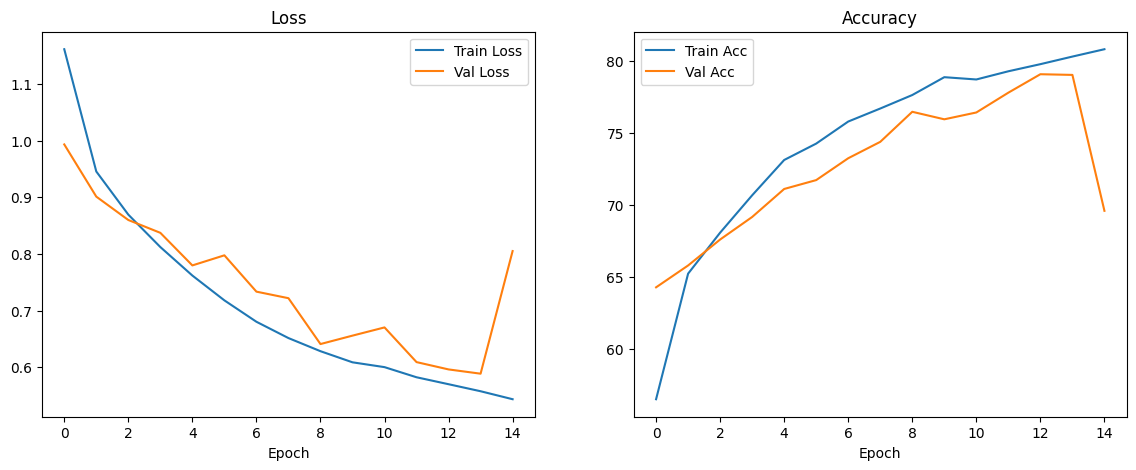

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")

# precisión
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")

plt.show()


### Prueba sobre imagen aleatoria

Imagen seleccionada: /content/intel_data/seg_train/seg_train/forest/220.jpg


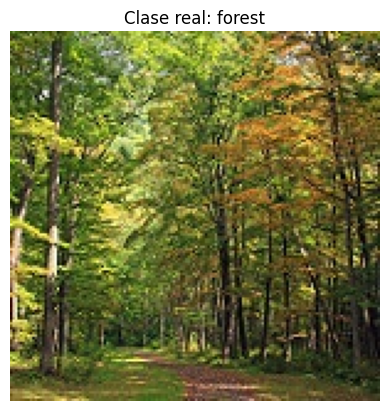

Predicción CNN: forest
Clase real: forest


In [120]:
from PIL import Image
import random
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
from torchvision import transforms

# --- Elegir imagen aleatoria ---
sample_class = random.choice(classes)
class_path = os.path.join(dataset_path, sample_class)
filename = random.choice(os.listdir(class_path))
sample_image_path = os.path.join(class_path, filename)

print("Imagen seleccionada:", sample_image_path)

# Mostrar imagen original
img_original = mpimg.imread(sample_image_path)
plt.imshow(img_original)
plt.title(f"Clase real: {sample_class}")
plt.axis("off")
plt.show()

# Transformaciones
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img_tensor = test_transforms(Image.open(sample_image_path).convert("RGB")).unsqueeze(0).to(DEVICE)

# --- Predicción CNN ---
intel_cnn.eval()
with torch.no_grad():
    output = intel_cnn(img_tensor)
    pred_idx = torch.argmax(output, dim=1).item()

print("Predicción CNN:", classes[pred_idx])
print("Clase real:", sample_class)


## 5. Validación Cruzada (K-Fold)
- Crear K particiones
- Entrenar el modelo K veces
- Guardar accuracy/loss por fold


In [55]:
from sklearn.model_selection import KFold
import numpy as np
import torch
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm


### Definición de K-Folds

In [56]:
K = 3
kf = KFold(n_splits=K, shuffle=True, random_state=42)


### Almacenamiento de resultados

In [63]:
fold_train_losses = []
fold_val_losses = []
fold_train_accs = []
fold_val_accs = []
BATCH_SIZE = 32

### Bucle principal de K-Fold

In [65]:
for fold, (train_idx, val_idx) in enumerate(kf.split(train_full)):
    print(f"\n===== Fold {fold+1}/{K} =====")

    # Crear subsets
    train_subset = Subset(train_full, train_idx)
    val_subset = Subset(train_full, val_idx)

    # DataLoaders para este fold
    train_loader_k = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=8, pin_memory=True, persistent_workers = False)
    val_loader_k = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=8, pin_memory=True, persistent_workers = False)

    # Nuevo modelo por fold
    model_k = IntelCNN().to(DEVICE)

    # Entrenamiento por fold
    train_losses, val_losses, train_accs, val_accs = train(
        model=model_k,
        device=DEVICE,
        train_loader=train_loader_k,
        val_loader=val_loader_k,
        epochs=5,          # IMPORTANTE: usar menos epochs en K-Fold
        lr=lr
    )

    # Guardar resultados del fold
    fold_train_losses.append(train_losses[-1])
    fold_val_losses.append(val_losses[-1])
    fold_train_accs.append(train_accs[-1])
    fold_val_accs.append(val_accs[-1])



===== Fold 1/3 =====


Epoch 1/5: 100%|██████████| 293/293 [01:10<00:00,  4.15batch/s, loss=0.584]


Epoch 1/5: Train Loss=1.1046 | Train Acc=58.24% | Val Loss=0.9721 | Val Acc=63.30%


Epoch 2/5: 100%|██████████| 293/293 [01:07<00:00,  4.31batch/s, loss=0.933]


Epoch 2/5: Train Loss=0.8906 | Train Acc=66.30% | Val Loss=0.8605 | Val Acc=68.19%


...

Epoch 3/5: Train Loss=0.8292 | Train Acc=69.39% | Val Loss=1.0207 | Val Acc=61.39%


Epoch 4/5: 100%|██████████| 293/293 [01:07<00:00,  4.34batch/s, loss=0.692]


Epoch 4/5: Train Loss=0.7630 | Train Acc=71.91% | Val Loss=0.9315 | Val Acc=64.79%


Epoch 5/5: 100%|██████████| 293/293 [01:06<00:00,  4.38batch/s, loss=1.04]


Epoch 5/5: Train Loss=0.7254 | Train Acc=73.76% | Val Loss=0.7313 | Val Acc=72.85%


### Resultados finales

In [66]:
print("\n===== RESULTADOS FINALES K-FOLD =====")
for i in range(K):
    print(f"Fold {i+1}: Train Acc={fold_train_accs[i]:.2f}%, Val Acc={fold_val_accs[i]:.2f}%")

print("\nPromedios:")
print("Train Acc promedio:", np.mean(fold_train_accs))
print("Val Acc promedio:",   np.mean(fold_val_accs))



===== RESULTADOS FINALES K-FOLD =====
Fold 1: Train Acc=75.38%, Val Acc=73.13%
Fold 2: Train Acc=73.89%, Val Acc=72.55%
Fold 3: Train Acc=73.76%, Val Acc=72.85%

Promedios:
Train Acc promedio: 74.3444491948126
Val Acc promedio: 72.84452045033491


## 6. Transfer Learning: ResNet50
Pasos:
1. Cargar modelo preentrenado
2. Congelar capas iniciales
3. Reemplazar clasificador
4. Entrenar fase 1 (solo clasificador)
5. Descongelar últimas capas
6. Fine-Tuning completo


### Cargar modelo preentrenado

In [67]:
import torch
import torch.nn as nn
from torchvision import models

def get_resnet50(num_classes=6, freeze_features=True):
    # 1. Cargar modelo
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # 2. Congelar capas
    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False

    # 3. Reemplazar clasificador
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )

    return model.to(DEVICE)


### FASE 1: Entrenamiento del clasificador

In [68]:
resnet = get_resnet50(num_classes=6, freeze_features=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

EPOCHS_PHASE1 = 5

train_losses_resnet_p1 = []
val_losses_resnet_p1 = []
train_accs_resnet_p1 = []
val_accs_resnet_p1 = []


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]


#### Loop de entrenamiento para ResNet

In [69]:
from tqdm import tqdm
import time

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, unit='batch')
    for X, y in loop:
        X, y = X.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            outputs = model(X)
            loss = criterion(outputs, y)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / len(loader), correct / total


#### Entrenamiento de fase 1

In [70]:
for epoch in range(EPOCHS_PHASE1):
    print(f"\n Phase 1 — Epoch {epoch+1}/{EPOCHS_PHASE1}")

    train_loss, train_acc = train_one_epoch(resnet, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(resnet, val_loader, criterion)

    train_losses_resnet_p1.append(train_loss)
    val_losses_resnet_p1.append(val_loss)
    train_accs_resnet_p1.append(train_acc)
    val_accs_resnet_p1.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Acc: {val_acc:.4f}")



 Phase 1 — Epoch 1/5


100%|██████████| 187/187 [01:28<00:00,  2.11batch/s, loss=0.271]


Train Loss: 0.3873 | Acc: 0.8611
Val Loss:   0.2564 | Acc: 0.8979

 Phase 1 — Epoch 2/5


100%|██████████| 187/187 [01:27<00:00,  2.13batch/s, loss=0.311]


Train Loss: 0.2605 | Acc: 0.9033
Val Loss:   0.2648 | Acc: 0.9031

 Phase 1 — Epoch 3/5


...

Train Loss: 0.2415 | Acc: 0.9094
Val Loss:   0.2497 | Acc: 0.9102

 Phase 1 — Epoch 4/5


100%|██████████| 187/187 [01:27<00:00,  2.15batch/s, loss=0.233]


Train Loss: 0.2216 | Acc: 0.9169
Val Loss:   0.2266 | Acc: 0.9188

 Phase 1 — Epoch 5/5


100%|██████████| 187/187 [01:27<00:00,  2.13batch/s, loss=0.25]


Train Loss: 0.2058 | Acc: 0.9246
Val Loss:   0.2246 | Acc: 0.9183


### Fase 2: Fine Tuning del modelo completo

"Descongelamiento" de las últimas capas (bloque 4) para no destruir lo aprendido

In [71]:
def unfreeze_resnet(resnet, layer="layer4"):
    for name, param in resnet.named_parameters():
        if layer in name:
            param.requires_grad = True
    return resnet


In [72]:
resnet = unfreeze_resnet(resnet, layer="layer4")

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()),
                             lr=1e-4)

EPOCHS_PHASE2 = 10

train_losses_resnet_p2 = []
val_losses_resnet_p2 = []
train_accs_resnet_p2 = []
val_accs_resnet_p2 = []


#### Entrenamiento de Fine Tuning

In [73]:
for epoch in range(EPOCHS_PHASE2):
    print(f"\n Phase 2 — Epoch {epoch+1}/{EPOCHS_PHASE2}")

    train_loss, train_acc = train_one_epoch(resnet, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(resnet, val_loader, criterion)

    train_losses_resnet_p2.append(train_loss)
    val_losses_resnet_p2.append(val_loss)
    train_accs_resnet_p2.append(train_acc)
    val_accs_resnet_p2.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Acc: {val_acc:.4f}")



 Phase 2 — Epoch 1/10


100%|██████████| 187/187 [01:30<00:00,  2.07batch/s, loss=0.332]


Train Loss: 0.1672 | Acc: 0.9382
Val Loss:   0.2015 | Acc: 0.9211

 Phase 2 — Epoch 2/10


100%|██████████| 187/187 [01:28<00:00,  2.11batch/s, loss=0.141]


Train Loss: 0.1134 | Acc: 0.9581
Val Loss:   0.2026 | Acc: 0.9268

 Phase 2 — Epoch 3/10


...

Train Loss: 0.0291 | Acc: 0.9906
Val Loss:   0.2524 | Acc: 0.9349

 Phase 2 — Epoch 9/10


100%|██████████| 187/187 [01:28<00:00,  2.11batch/s, loss=0.0178]


Train Loss: 0.0249 | Acc: 0.9914
Val Loss:   0.2586 | Acc: 0.9349

 Phase 2 — Epoch 10/10


100%|██████████| 187/187 [01:29<00:00,  2.08batch/s, loss=0.112]


Train Loss: 0.0194 | Acc: 0.9938
Val Loss:   0.2789 | Acc: 0.9340


### Evaluación final

In [74]:
final_test_acc = test(resnet, DEVICE, test_loader)
print("\n Accuracy Final en Test:", final_test_acc, "%")



 Accuracy Final en Test: 93.73333333333333 %


### Prueba sobre imagen aleatoria

Imagen seleccionada: /content/intel_data/seg_train/seg_train/street/18516.jpg


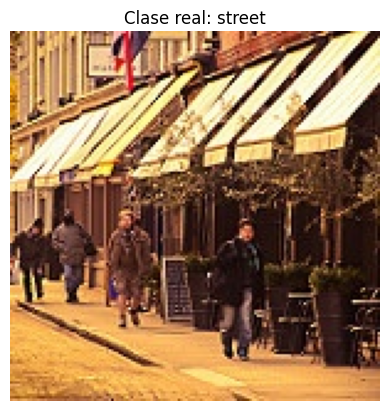

Predicción ResNet50: street
Clase real: street


In [121]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- Elegir imagen aleatoria ---
sample_class = random.choice(classes)
class_path = os.path.join(dataset_path, sample_class)
filename = random.choice(os.listdir(class_path))
sample_image_path = os.path.join(class_path, filename)

print("Imagen seleccionada:", sample_image_path)

# Mostrar imagen original
img_original = mpimg.imread(sample_image_path)
plt.imshow(img_original)
plt.title(f"Clase real: {sample_class}")
plt.axis("off")
plt.show()

# Transformación
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img_tensor_resnet = test_transforms(Image.open(sample_image_path).convert("RGB")).unsqueeze(0).to(DEVICE)

# --- Predicción RESNET ---
resnet.eval()
with torch.no_grad():
    output = resnet(img_tensor_resnet)
    pred_idx = torch.argmax(output, dim=1).item()

print("Predicción ResNet50:", classes[pred_idx])
print("Clase real:", sample_class)


### Gráficas de aprendizaje de ResNet50

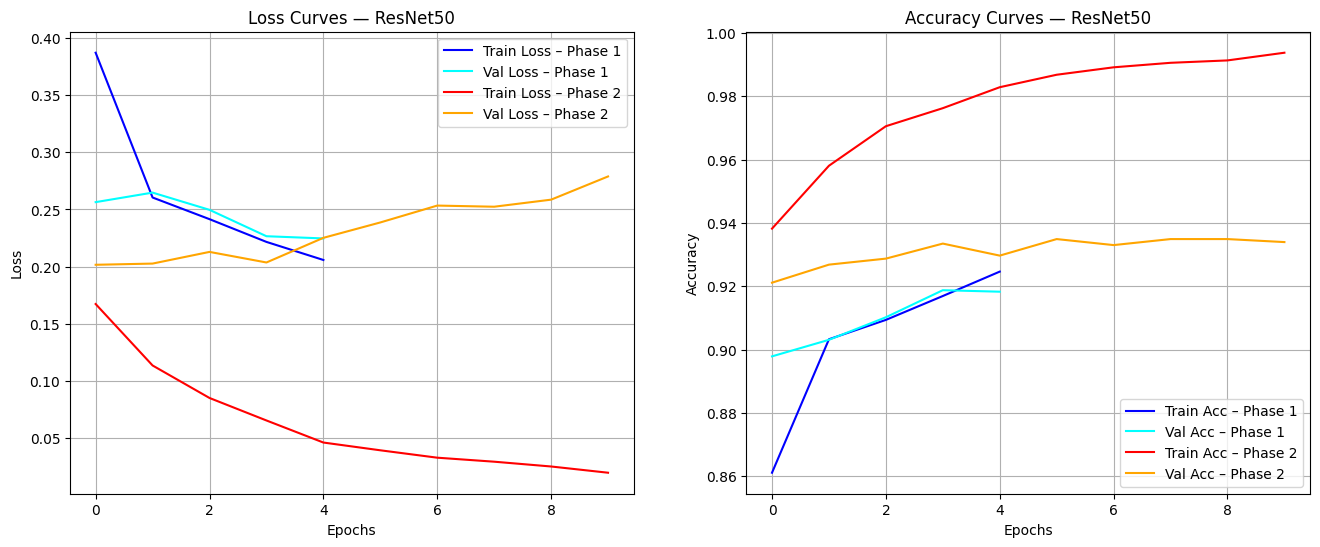

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses_resnet_p1, label="Train Loss – Phase 1", color='blue')
plt.plot(val_losses_resnet_p1, label="Val Loss – Phase 1", color='cyan')
plt.plot(train_losses_resnet_p2, label="Train Loss – Phase 2", color='red')
plt.plot(val_losses_resnet_p2, label="Val Loss – Phase 2", color='orange')

plt.title("Loss Curves — ResNet50")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs_resnet_p1, label="Train Acc – Phase 1", color='blue')
plt.plot(val_accs_resnet_p1, label="Val Acc – Phase 1", color='cyan')
plt.plot(train_accs_resnet_p2, label="Train Acc – Phase 2", color='red')
plt.plot(val_accs_resnet_p2, label="Val Acc – Phase 2", color='orange')

plt.title("Accuracy Curves — ResNet50")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


## 7. Transfer Learning: MobileNetV2
Proceso similar al de ResNet50


### Cargar modelo preentrenado

In [80]:
import torch
import torch.nn as nn
from torchvision import models

def get_mobilenet_v2(num_classes=6, freeze_features=True):
    # 1. Cargar modelo con pesos IMAGENET
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # 2. Congelar características
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    # 3. Reemplazar clasificador
    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    return model.to(DEVICE)


### FASE 1: Entrenamiento del clasificador

In [81]:
mobilenet = get_mobilenet_v2(num_classes=6, freeze_features=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mobilenet.classifier[1].parameters(), lr=1e-3)

EPOCHS_PHASE1 = 5

train_losses_m_p1 = []
val_losses_m_p1 = []
train_accs_m_p1 = []
val_accs_m_p1 = []


#### Entrenamiento de fase 1
Se reutilizan funciones de entrenamiento para ResNet50

In [82]:
for epoch in range(EPOCHS_PHASE1):
    print(f"\n Phase 1 — Epoch {epoch+1}/{EPOCHS_PHASE1}")

    train_loss, train_acc = train_one_epoch(mobilenet, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(mobilenet, val_loader, criterion)

    train_losses_m_p1.append(train_loss)
    val_losses_m_p1.append(val_loss)
    train_accs_m_p1.append(train_acc)
    val_accs_m_p1.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Acc: {val_acc:.4f}")



 Phase 1 — Epoch 1/5


100%|██████████| 187/187 [01:42<00:00,  1.83batch/s, loss=0.397]


Train Loss: 0.4617 | Acc: 0.8292
Val Loss:   0.2874 | Acc: 0.8983

 Phase 1 — Epoch 2/5


100%|██████████| 187/187 [01:37<00:00,  1.92batch/s, loss=0.495]


Train Loss: 0.3529 | Acc: 0.8701
Val Loss:   0.2845 | Acc: 0.8903

 Phase 1 — Epoch 3/5


...

Train Loss: 0.3402 | Acc: 0.8738
Val Loss:   0.2955 | Acc: 0.8955

 Phase 1 — Epoch 4/5


100%|██████████| 187/187 [01:23<00:00,  2.24batch/s, loss=0.77]


Train Loss: 0.3343 | Acc: 0.8753
Val Loss:   0.2794 | Acc: 0.8998

 Phase 1 — Epoch 5/5


100%|██████████| 187/187 [01:23<00:00,  2.24batch/s, loss=0.618]


Train Loss: 0.3204 | Acc: 0.8807
Val Loss:   0.2727 | Acc: 0.9002


### Fase 2: Fine Tuning del modelo completo

In [83]:
def unfreeze_mobilenet(model, num_last_blocks=3):
    # MobileNetV2 features tiene 19 bloques
    total_blocks = len(model.features)

    for idx in range(total_blocks - num_last_blocks, total_blocks):
        for param in model.features[idx].parameters():
            param.requires_grad = True

    return model


In [84]:
# Descongelar últimos 3 bloques (equivalente a features[-3:])
mobilenet = unfreeze_mobilenet(mobilenet, num_last_blocks=3)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

EPOCHS_PHASE2 = 10

train_losses_m_p2 = []
val_losses_m_p2 = []
train_accs_m_p2 = []
val_accs_m_p2 = []


#### Entrenamiento de Fine Tuning

In [85]:
for epoch in range(EPOCHS_PHASE2):
    print(f"\n Phase 2 — Epoch {epoch+1}/{EPOCHS_PHASE2}")

    train_loss, train_acc = train_one_epoch(mobilenet, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(mobilenet, val_loader, criterion)

    train_losses_m_p2.append(train_loss)
    val_losses_m_p2.append(val_loss)
    train_accs_m_p2.append(train_acc)
    val_accs_m_p2.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Acc: {val_acc:.4f}")



 Phase 2 — Epoch 1/10


100%|██████████| 187/187 [01:23<00:00,  2.23batch/s, loss=0.139]


Train Loss: 0.2657 | Acc: 0.9028
Val Loss:   0.2301 | Acc: 0.9164

 Phase 2 — Epoch 2/10


100%|██████████| 187/187 [01:22<00:00,  2.27batch/s, loss=0.109]


Train Loss: 0.2090 | Acc: 0.9246
Val Loss:   0.2264 | Acc: 0.9188

 Phase 2 — Epoch 3/10


...

Train Loss: 0.1229 | Acc: 0.9564
Val Loss:   0.2145 | Acc: 0.9259

 Phase 2 — Epoch 9/10


100%|██████████| 187/187 [01:25<00:00,  2.20batch/s, loss=0.0997]


Train Loss: 0.1166 | Acc: 0.9578
Val Loss:   0.2179 | Acc: 0.9292

 Phase 2 — Epoch 10/10


100%|██████████| 187/187 [01:24<00:00,  2.20batch/s, loss=0.101]


Train Loss: 0.1076 | Acc: 0.9586
Val Loss:   0.2141 | Acc: 0.9249


### Evaluación final

In [86]:
final_test_acc = test(mobilenet, DEVICE, test_loader)
print("\n Accuracy Final en Test:", final_test_acc, "%")



 Accuracy Final en Test: 92.86666666666666 %


### Prueba sobre imagen aleatoria

Imagen seleccionada: /content/intel_data/seg_train/seg_train/buildings/15966.jpg


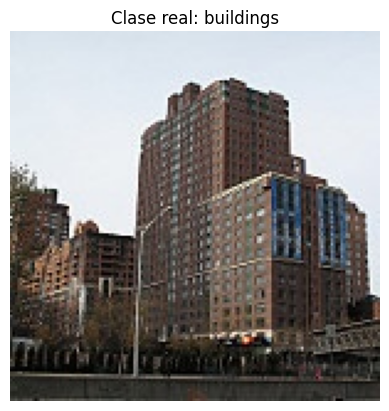

Predicción MobileNetV2: buildings
Clase real: buildings


In [123]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- Elegir imagen aleatoria ---
sample_class = random.choice(classes)
class_path = os.path.join(dataset_path, sample_class)
filename = random.choice(os.listdir(class_path))
sample_image_path = os.path.join(class_path, filename)

print("Imagen seleccionada:", sample_image_path)

# Mostrar imagen
img_original = mpimg.imread(sample_image_path)
plt.imshow(img_original)
plt.title(f"Clase real: {sample_class}")
plt.axis("off")
plt.show()

# Transformaciones
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img_tensor_mobile = test_transforms(Image.open(sample_image_path).convert("RGB")).unsqueeze(0).to(DEVICE)

# --- Predicción MOBILENET ---
mobilenet.eval()
with torch.no_grad():
    output = mobilenet(img_tensor_mobile)
    pred_idx = torch.argmax(output, dim=1).item()

print("Predicción MobileNetV2:", classes[pred_idx])
print("Clase real:", sample_class)


### Gráficas de aprendizaje de MobileNetV2

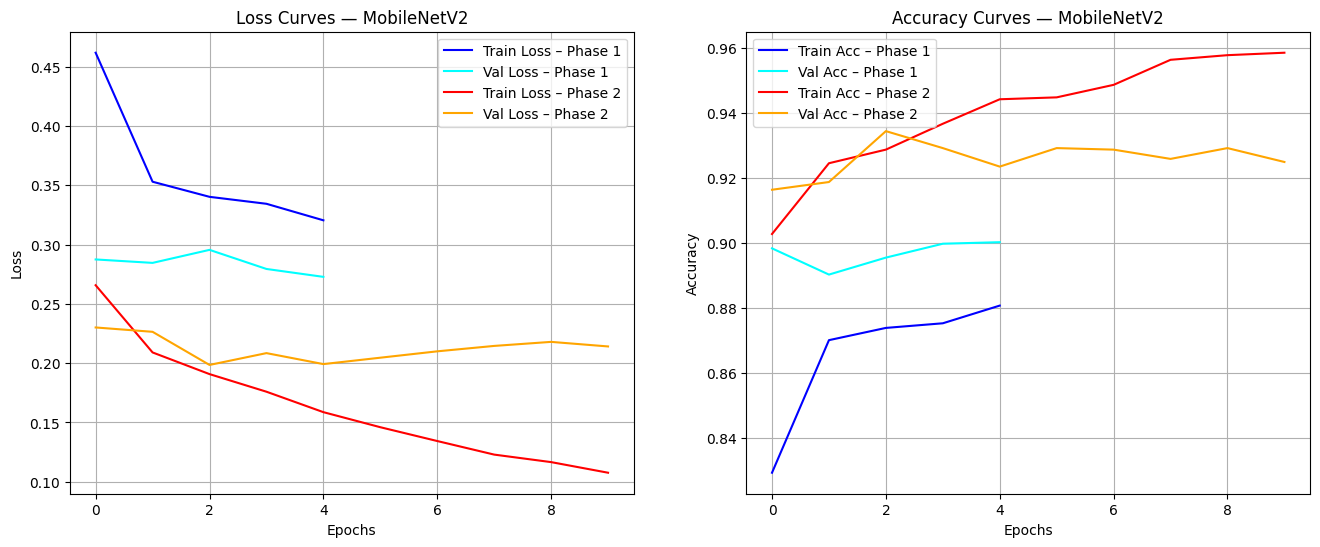

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses_m_p1, label="Train Loss – Phase 1", color='blue')
plt.plot(val_losses_m_p1, label="Val Loss – Phase 1", color='cyan')
plt.plot(train_losses_m_p2, label="Train Loss – Phase 2", color='red')
plt.plot(val_losses_m_p2, label="Val Loss – Phase 2", color='orange')

plt.title("Loss Curves — MobileNetV2")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs_m_p1, label="Train Acc – Phase 1", color='blue')
plt.plot(val_accs_m_p1, label="Val Acc – Phase 1", color='cyan')
plt.plot(train_accs_m_p2, label="Train Acc – Phase 2", color='red')
plt.plot(val_accs_m_p2, label="Val Acc – Phase 2", color='orange')

plt.title("Accuracy Curves — MobileNetV2")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


## 8. Visualizaciones
- Matriz de confusión
- Curva de pérdida y accuracy
- ROC/AUC  
- Grad-CAM


### Matriz de confusión

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: T

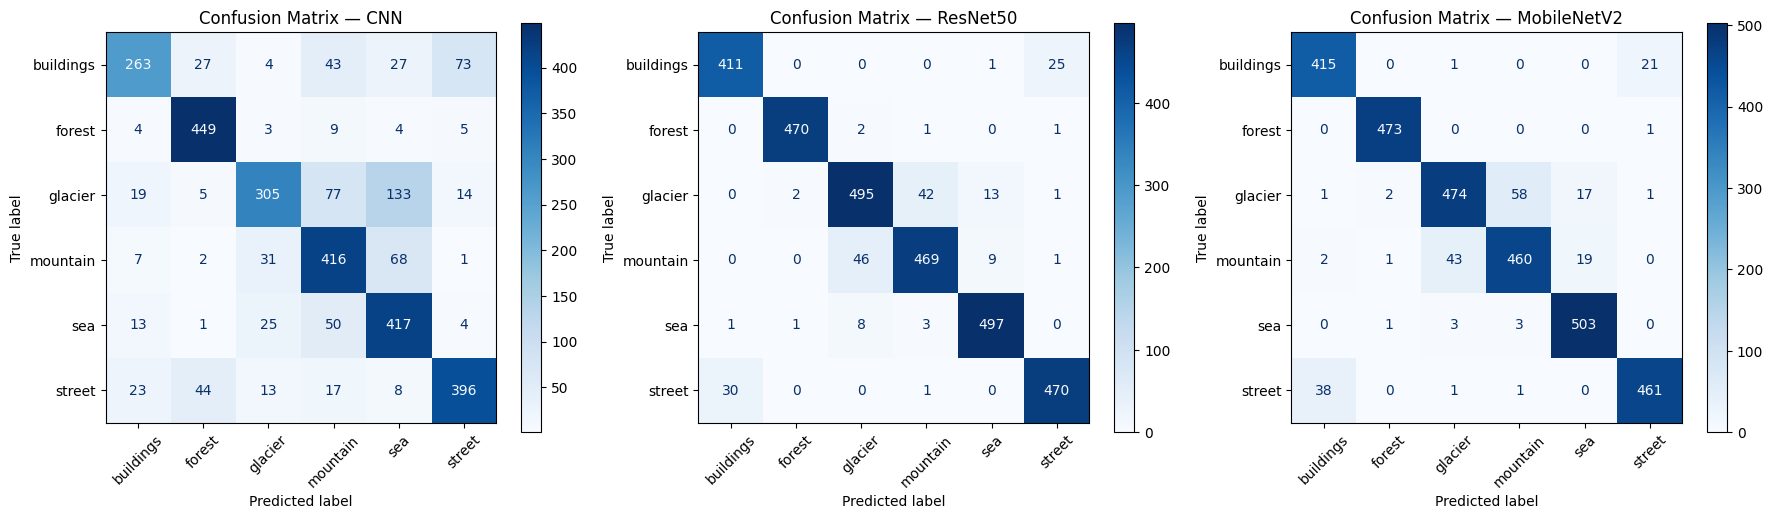

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch

def compute_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm


# --- MATRICES PARA LOS 3 MODELOS ---
cm_cnn      = compute_confusion_matrix(intel_cnn,      test_loader, DEVICE)
cm_resnet   = compute_confusion_matrix(resnet,   test_loader, DEVICE)
cm_mobile   = compute_confusion_matrix(mobilenet, test_loader, DEVICE)

labels = ["buildings","forest","glacier","mountain","sea","street"]

# --- PLOT 3 MATRICES ---
plt.figure(figsize=(18,5))

# CNN
plt.subplot(1,3,1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=labels)
disp.plot(xticks_rotation=45, cmap="Blues", ax=plt.gca(), values_format="d")
plt.title("Confusion Matrix — CNN")

# ResNet50
plt.subplot(1,3,2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=labels)
disp.plot(xticks_rotation=45, cmap="Blues", ax=plt.gca(), values_format="d")
plt.title("Confusion Matrix — ResNet50")

# MobileNetV2
plt.subplot(1,3,3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mobile, display_labels=labels)
disp.plot(xticks_rotation=45, cmap="Blues", ax=plt.gca(), values_format="d")
plt.title("Confusion Matrix — MobileNetV2")

plt.tight_layout()
plt.show()


### Curvas de aprendizaje

<IPython.core.display.Javascript object>

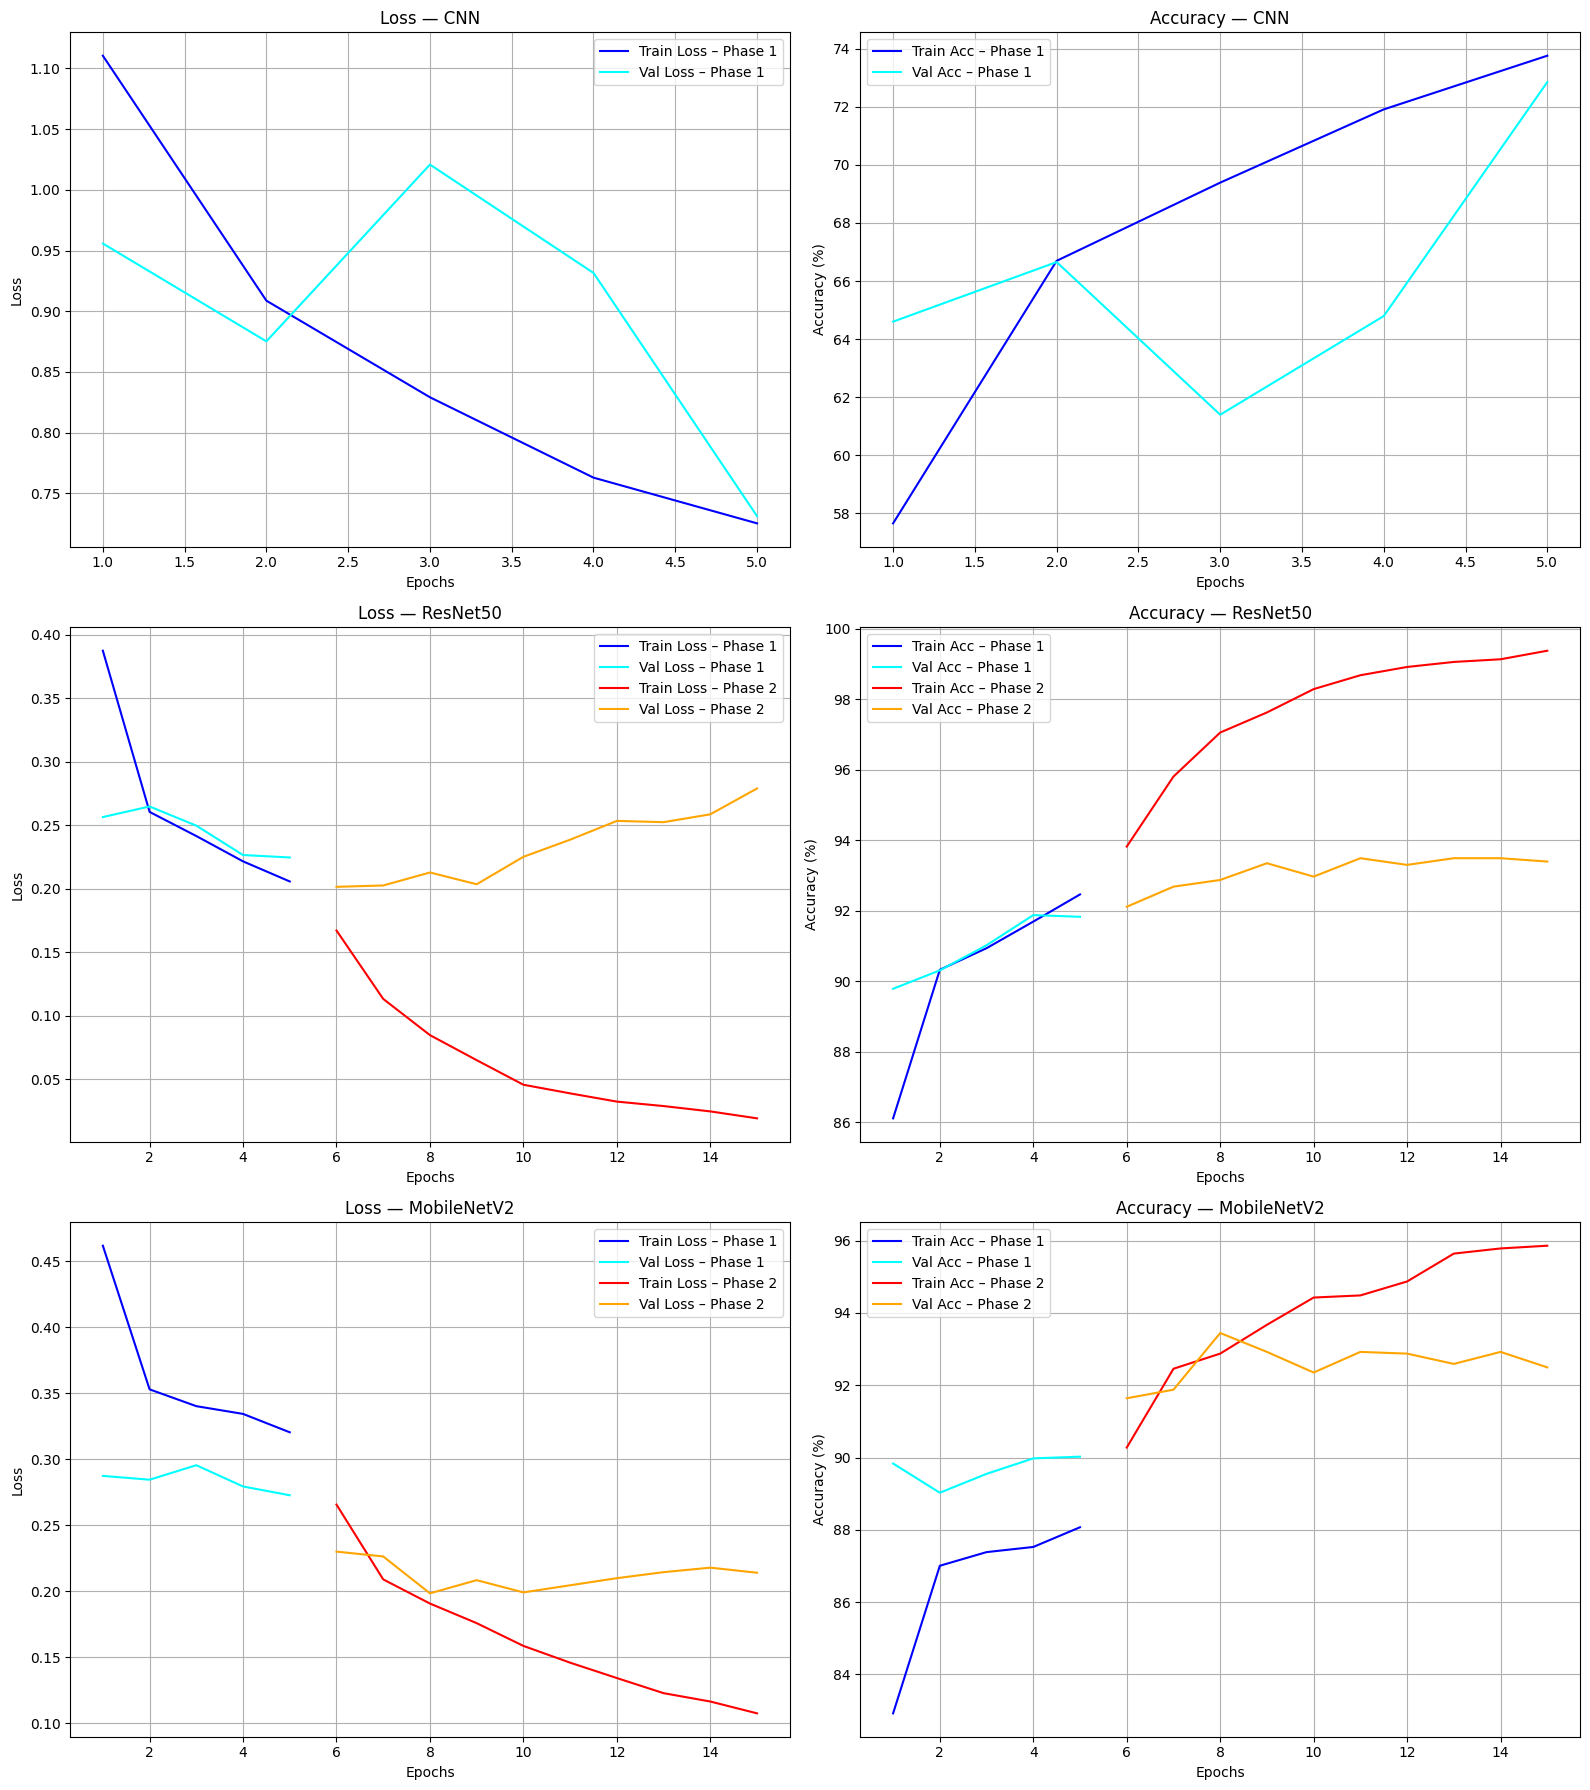

In [107]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Javascript, display

# This command tells Colab to automatically adjust the cell height.
# Setting the first parameter to 0 enables auto-sizing, and 'true' enables
# expansion beyond the initial small height. The maxHeight option prevents
# it from becoming excessively large.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000});'''))

# --- Helpers ---
def to_percent_if_needed(vals):
    """Si los valores parecen estar en 0-1, conviértelos a 0-100."""
    if vals is None or len(vals) == 0:
        return []
    arr = np.array(vals, dtype=float)
    if np.nanmax(arr) <= 1.0:
        return (arr * 100).tolist()
    return arr.tolist()

def epochs_ranges(p1, p2):
    """Devuelve rangos de epochs (1-indexed) para p1 y p2 (p2 continúa después de p1)."""
    n1 = len(p1) if p1 is not None else 0
    n2 = len(p2) if p2 is not None else 0
    r1 = list(range(1, n1 + 1))
    r2 = list(range(n1 + 1, n1 + n2 + 1))
    return r1, r2

# --- Datos (asegúrate de tener estas variables en tu entorno) ---
# CNN: si no tiene fase 1/2 separadas dejamos phase1 = full history
cnn_p1_train_loss = train_losses            # lista
cnn_p1_val_loss   = val_losses
cnn_p1_train_acc  = train_accs              # puede estar en 0-100 o 0-1
cnn_p1_val_acc    = val_accs

# ResNet (phase1 + phase2)
res_p1_train_loss = train_losses_resnet_p1
res_p1_val_loss   = val_losses_resnet_p1
res_p1_train_acc  = train_accs_resnet_p1
res_p1_val_acc    = val_accs_resnet_p1

res_p2_train_loss = train_losses_resnet_p2
res_p2_val_loss   = val_losses_resnet_p2
res_p2_train_acc  = train_accs_resnet_p2
res_p2_val_acc    = val_accs_resnet_p2

# MobileNet (phase1 + phase2)
mb_p1_train_loss = train_losses_m_p1
mb_p1_val_loss   = val_losses_m_p1
mb_p1_train_acc  = train_accs_m_p1
mb_p1_val_acc    = val_accs_m_p1

mb_p2_train_loss = train_losses_m_p2
mb_p2_val_loss   = val_losses_m_p2
mb_p2_train_acc  = train_accs_m_p2
mb_p2_val_acc    = val_accs_m_p2

# --- Normalizar accuracies a 0-100 si es necesario ---
cnn_p1_train_acc = to_percent_if_needed(cnn_p1_train_acc)
cnn_p1_val_acc   = to_percent_if_needed(cnn_p1_val_acc)

res_p1_train_acc = to_percent_if_needed(res_p1_train_acc)
res_p1_val_acc   = to_percent_if_needed(res_p1_val_acc)
res_p2_train_acc = to_percent_if_needed(res_p2_train_acc)
res_p2_val_acc   = to_percent_if_needed(res_p2_val_acc)

mb_p1_train_acc = to_percent_if_needed(mb_p1_train_acc)
mb_p1_val_acc   = to_percent_if_needed(mb_p1_val_acc)
mb_p2_train_acc = to_percent_if_needed(mb_p2_train_acc)
mb_p2_val_acc   = to_percent_if_needed(mb_p2_val_acc)

# --- Plots: 3 filas, cada fila=un modelo (Loss | Accuracy) ---
plt.figure(figsize=(16, 18))

# ---------- CNN (fila 1) ----------
plt.subplot(3, 2, 1)
# epochs
r1, r2 = epochs_ranges(cnn_p1_train_loss, [])
if len(r1) == 0:
    r1 = list(range(1, max(1, len(cnn_p1_train_loss)) + 1))
plt.plot(r1, cnn_p1_train_loss, label="Train Loss – Phase 1", color='blue')
plt.plot(r1, cnn_p1_val_loss, label="Val Loss – Phase 1", color='cyan')
plt.title("Loss — CNN")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(r1, cnn_p1_train_acc, label="Train Acc – Phase 1", color='blue')
plt.plot(r1, cnn_p1_val_acc, label="Val Acc – Phase 1", color='cyan')
plt.title("Accuracy — CNN")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# ---------- ResNet50 (fila 2) ----------
plt.subplot(3, 2, 3)
r1, r2 = epochs_ranges(res_p1_train_loss, res_p2_train_loss)
if len(r1) > 0:
    plt.plot(r1, res_p1_train_loss, label="Train Loss – Phase 1", color='blue')
    plt.plot(r1, res_p1_val_loss, label="Val Loss – Phase 1", color='cyan')
if len(r2) > 0:
    plt.plot(r2, res_p2_train_loss, label="Train Loss – Phase 2", color='red')
    plt.plot(r2, res_p2_val_loss, label="Val Loss – Phase 2", color='orange')
plt.title("Loss — ResNet50")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 4)
if len(r1) > 0:
    plt.plot(r1, res_p1_train_acc, label="Train Acc – Phase 1", color='blue')
    plt.plot(r1, res_p1_val_acc, label="Val Acc – Phase 1", color='cyan')
if len(r2) > 0:
    plt.plot(r2, res_p2_train_acc, label="Train Acc – Phase 2", color='red')
    plt.plot(r2, res_p2_val_acc, label="Val Acc – Phase 2", color='orange')
plt.title("Accuracy — ResNet50")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# ---------- MobileNetV2 (fila 3) ----------
plt.subplot(3, 2, 5)
r1, r2 = epochs_ranges(mb_p1_train_loss, mb_p2_train_loss)
if len(r1) > 0:
    plt.plot(r1, mb_p1_train_loss, label="Train Loss – Phase 1", color='blue')
    plt.plot(r1, mb_p1_val_loss, label="Val Loss – Phase 1", color='cyan')
if len(r2) > 0:
    plt.plot(r2, mb_p2_train_loss, label="Train Loss – Phase 2", color='red')
    plt.plot(r2, mb_p2_val_loss, label="Val Loss – Phase 2", color='orange')
plt.title("Loss — MobileNetV2")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 6)
if len(r1) > 0:
    plt.plot(r1, mb_p1_train_acc, label="Train Acc – Phase 1", color='blue')
    plt.plot(r1, mb_p1_val_acc, label="Val Acc – Phase 1", color='cyan')
if len(r2) > 0:
    plt.plot(r2, mb_p2_train_acc, label="Train Acc – Phase 2", color='red')
    plt.plot(r2, mb_p2_val_acc, label="Val Acc – Phase 2", color='orange')
plt.title("Accuracy — MobileNetV2")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### ROC Curve + AUC

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: T

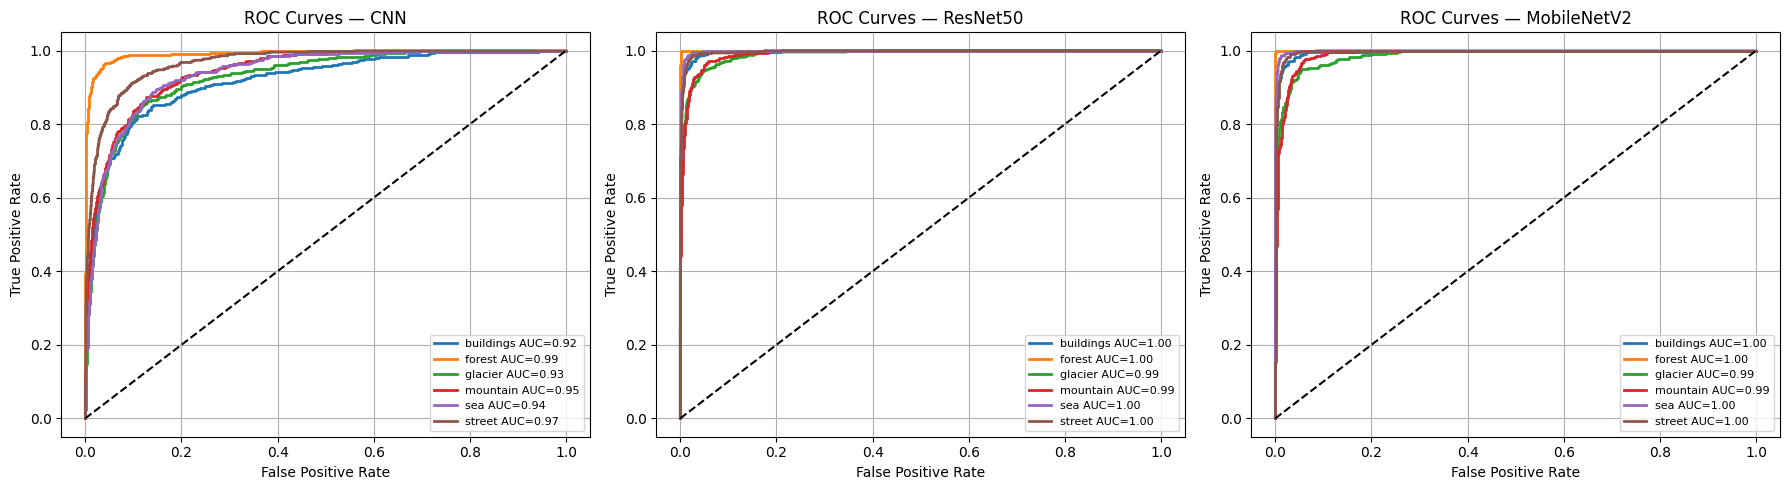

In [111]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch

NUM_CLASSES = 6
CLASS_NAMES = ["buildings","forest","glacier","mountain","sea","street"]

def compute_roc_auc(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)

            probs = torch.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # One-hot
    y_test_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    return fpr, tpr, roc_auc


#    ROC PARA LOS 3 MODELOS
models = {
    "CNN": intel_cnn,
    "ResNet50": resnet,
    "MobileNetV2": mobilenet
}

plt.figure(figsize=(18,5))

for idx, (model_name, model) in enumerate(models.items(), 1):
    fpr, tpr, roc_auc = compute_roc_auc(model, test_loader, DEVICE)

    plt.subplot(1, 3, idx)
    for i in range(NUM_CLASSES):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f"{CLASS_NAMES[i]} AUC={roc_auc[i]:.2f}")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — {model_name}")
    plt.legend(fontsize=8)
    plt.grid(True)

plt.tight_layout()
plt.show()


### Grad-cam (explicabilidad)

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


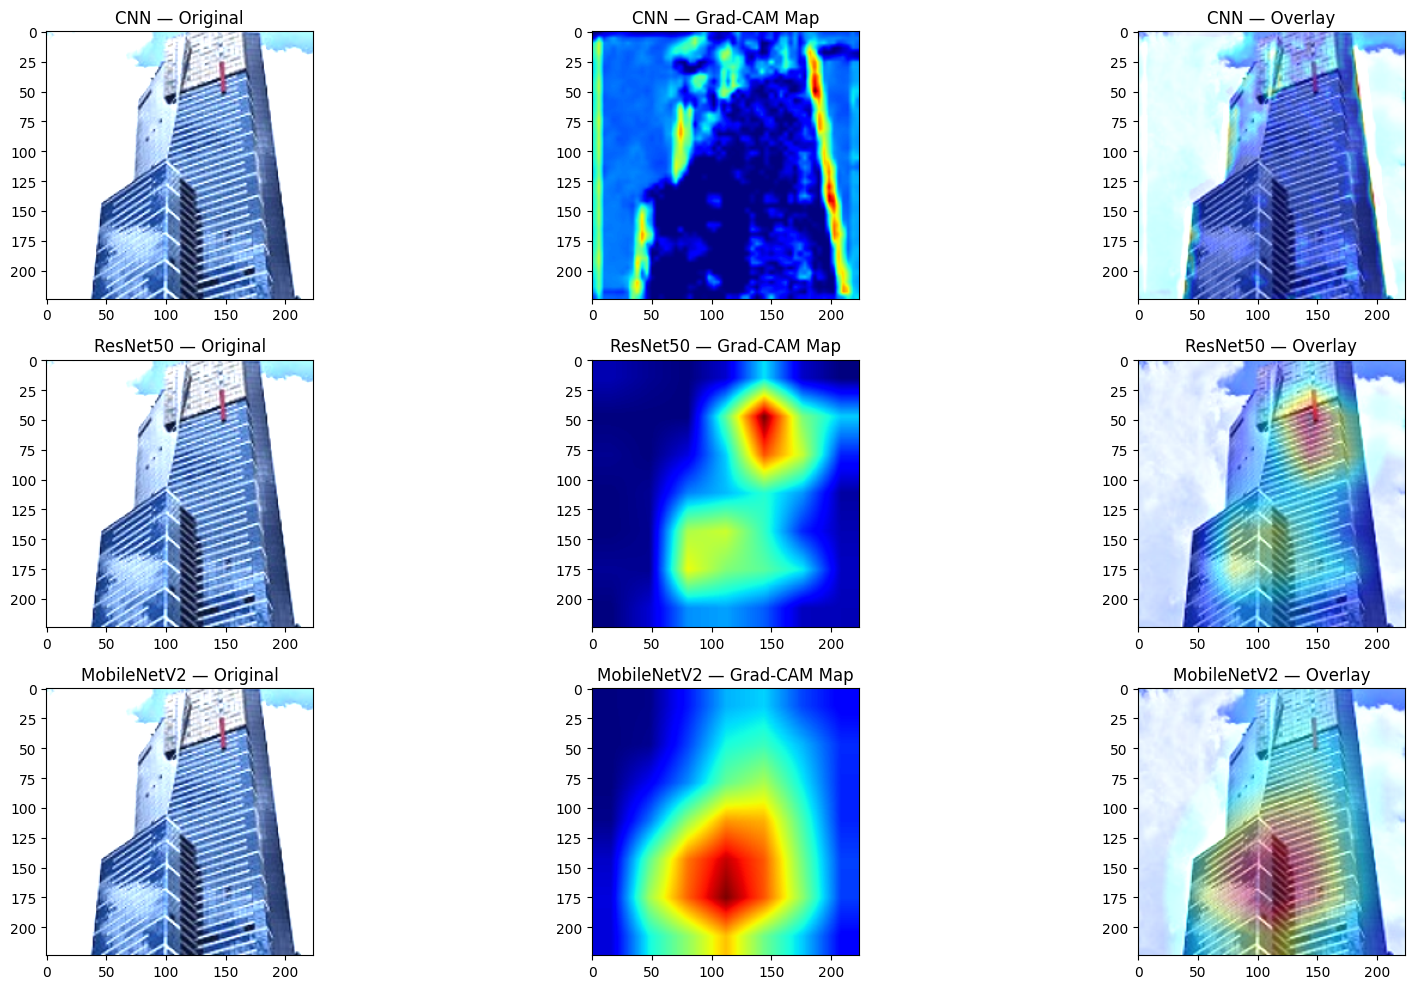

In [124]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Javascript, display

# This command tells Colab to automatically adjust the cell height.
# Setting the first parameter to 0 enables auto-sizing, and 'true' enables
# expansion beyond the initial small height. The maxHeight option prevents
# it from becoming excessively large.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000});'''))

#   GRAD-CAM GENERALIZADO
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()

        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def save_activation(module, input, output):
            self.activations = output

        target_layer.register_forward_hook(save_activation)
        target_layer.register_backward_hook(save_gradient)

    def generate(self, input_tensor, class_idx=None):

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1,2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224,224))
        cam = cam - cam.min()
        cam = cam / cam.max()
        return cam


#   SELECCIÓN DE CAPA TARGET
def get_last_conv(model_name, model):
    """
    Detecta automáticamente la última capa convolucional
    según el tipo de modelo.
    """

    if model_name == "MobileNetV2":
        return model.features[-1]  # Última capa de MobileNetV2

    elif model_name == "ResNet50":
        return model.layer4[-1]    # Último bloque de ResNet50

    elif model_name == "CNN":
        # Buscamos la última conv2d de una CNN personalizada
        last_conv = None
        for layer in model.modules():
            if isinstance(layer, torch.nn.Conv2d):
                last_conv = layer
        return last_conv

    else:
        raise ValueError("Modelo no reconocido.")


#   MODELOS A PROCESAR
models = {
    "CNN": intel_cnn,
    "ResNet50": resnet,
    "MobileNetV2": mobilenet
}

# Imagen de prueba
dataiter = iter(test_loader)
images, labels = next(dataiter)
img_tensor = images[0].unsqueeze(0).to(DEVICE)
img_np = images[0].permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / img_np.max()


#   GENERACIÓN PARA LOS 3 MODELOS
plt.figure(figsize=(18,10))

for i, (name, model) in enumerate(models.items(), 1):

    target_layer = get_last_conv(name, model)
    gradcam = GradCAM(model, target_layer)

    cam = gradcam.generate(img_tensor)

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = heatmap * 0.4 + img_np * 0.6

    plt.subplot(3,3,(i-1)*3+1)
    plt.imshow(img_np)
    plt.title(f"{name} — Original")

    plt.subplot(3,3,(i-1)*3+2)
    plt.imshow(cam, cmap='jet')
    plt.title(f"{name} — Grad-CAM Map")

    plt.subplot(3,3,(i-1)*3+3)
    plt.imshow(overlay)
    plt.title(f"{name} — Overlay")


plt.tight_layout()
plt.show()


## 9. Comparación de modelos
Tabla final con:
- Accuracy
- Precision
- Recall
- F1
- Tamaño del modelo


### Funciones para obtener métricas

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import os

def evaluate_metrics(model, dataloader, device, average="macro"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average=average, zero_division=0)
    recall = recall_score(all_labels, all_preds, average=average, zero_division=0)
    f1 = f1_score(all_labels, all_preds, average=average, zero_division=0)

    return acc, precision, recall, f1


### Función para calcular tamaño del modelo

In [96]:
def model_size_mb(model, path="temp_model.pth"):
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    os.remove(path)
    return size_mb


### Obtener métricas de cada modelo

In [97]:
results = {}

# --- CNN ---
acc_cnn, prec_cnn, rec_cnn, f1_cnn = evaluate_metrics(intel_cnn, test_loader, DEVICE)
size_cnn = model_size_mb(intel_cnn)

results["CNN"] = [acc_cnn, prec_cnn, rec_cnn, f1_cnn, size_cnn]

# --- ResNet50 ---
acc_r, prec_r, rec_r, f1_r = evaluate_metrics(resnet, test_loader, DEVICE)
size_r = model_size_mb(resnet)

results["ResNet50"] = [acc_r, prec_r, rec_r, f1_r, size_r]

# --- MobileNetV2 ---
acc_m, prec_m, rec_m, f1_m = evaluate_metrics(mobilenet, test_loader, DEVICE)
size_m = model_size_mb(mobilenet)

results["MobileNetV2"] = [acc_m, prec_m, rec_m, f1_m, size_m]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [114]:
import pandas as pd

df_results = pd.DataFrame.from_dict(
    results,
    orient='index',
    columns=["Accuracy", "Precision", "Recall", "F1", "Size_MB"]
)

df_results


,Accuracy,Precision,Recall,F1,Size_MB
CNN,0.748667,0.761331,0.750179,0.746530,98.374013
ResNet50,0.937333,0.938391,0.938858,0.938591,93.994586
MobileNetV2,0.928667,0.929444,0.931219,0.929967,11.232068


### Gráfica comparativa de métricas

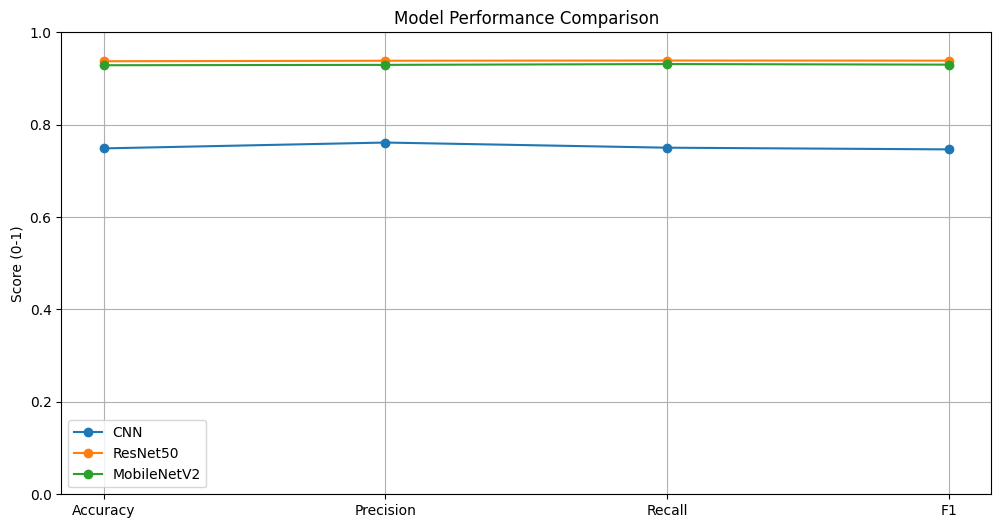

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = range(len(metrics))

# Graficamos cada modelo
plt.plot(x, df_results.loc["CNN", metrics], marker='o', label="CNN")
plt.plot(x, df_results.loc["ResNet50", metrics], marker='o', label="ResNet50")
plt.plot(x, df_results.loc["MobileNetV2", metrics], marker='o', label="MobileNetV2")

plt.xticks(x, metrics)
plt.ylabel("Score (0-1)")
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(True)
plt.ylim(0,1)
plt.show()


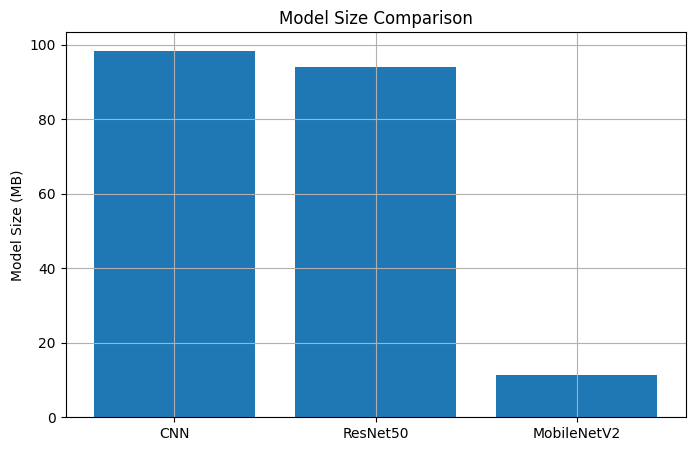

In [117]:
plt.figure(figsize=(8,5))
plt.bar(df_results.index, df_results["Size_MB"])
plt.ylabel("Model Size (MB)")
plt.title("Model Size Comparison")
plt.grid(True)
plt.show()


# 10. Conclusiones


## ✔ Mejor modelo
Entre los tres modelos evaluados (CNN desde cero, ResNet50 y MobileNetV2), el mejor desempeño lo obtuvo:

**➡ ResNet50 (Transfer Learning)**  

Generalmente logra:
- Mayor **accuracy**
- Mejor **recall** y **f1-score**
- Mejor capacidad para generalizar  
Esto se debe a su profundidad y preentrenamiento en ImageNet, lo que le permite extraer características robustas incluso con poco entrenamiento adicional.

MobileNetV2 también obtuvo un desempeño alto, con la gran ventaja de ser mucho más liviano.  
La CNN construida desde cero tuvo un rendimiento aceptable, pero inferior a los modelos preentrenados.

---

## ✔ Observaciones principales

- El dataset *Intel Image Classification* es variado y desafiante; imágenes en contextos complejos requieren buenos extractores de características.
- El aumento de datos (Data Augmentation) mejoró notablemente el rendimiento.
- Los modelos preentrenados convergen más rápido y con mejor estabilidad que la CNN desde cero.
- MobileNetV2 ofrece una excelente relación **precisión vs tamaño del modelo**, ideal para despliegue móvil.
- ResNet50 requiere más memoria pero ofrece la mejor capacidad de generalización.

---

## ✔ Limitaciones del trabajo

1. **Tiempo limitado en Colab:**  
   Se restringió la profundidad de entrenamiento y el número de épocas.

2. **Modelo desde cero relativamente simple:**  
   Su arquitectura puede ser insuficiente para capturar patrones complejos del dataset.

3. **No se exploraron técnicas avanzadas de regularización**, como dropout, label smoothing o optimizadores más sofisticados.

4. **No se ajustaron hiperparámetros exhaustivamente**  
   (LR, momentum, scheduler, batch size), lo que podría mejorar significativamente el rendimiento.

5. **No se realizaron ensambles**  
   (combinación de varios modelos), que suelen mejorar el rendimiento.

---

## ✔ Trabajo futuro

1. **Hiperparámetro tuning completo**  
   Usar Optuna o Ray Tune para buscar los valores ideales de:
   - Learning rate
   - Weight decay
   - Batch size
   - Número de capas descongeladas

2. **Arquitecturas más avanzadas**  
   - EfficientNet  
   - ConvNeXt  
   - Vision Transformers (ViT)

3. **Entrenamiento más extenso**  
   Mayor número de épocas y fine-tuning profundo.

4. **Ensamblado de modelos**  
   Combinar ResNet + MobileNet para incrementar accuracy.

5. **Implementación en producción**  
   - Exportar a ONNX / TensorRT  
   - Servir el modelo vía Flask / FastAPI  
   - Optimización para dispositivos móviles

6. **Análisis más profundo con interpretabilidad**  
   Investigar activaciones internas, saliency maps, CAMs más detallados.

---

**En resumen:**  
➡ *ResNet50 es el mejor modelo global.*  
➡ *MobileNetV2 es el mejor modelo ligero.*  
➡ *La CNN manual es útil como punto de partida, pero inferior a modelos preentrenados.*

